In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
oal = client.query(f"""
                    SELECT 
                        'not assigned' AS fak_name,
                        'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth' AS parent_name,
                        raw_affiliation_string,
                        openalex_id
                    FROM (
                      SELECT oal.id AS openalex_id, inst.address_full AS raw_affiliation_string
                      FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                      JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                          ON inst.inst_id_top = kb_inst.inst_id
                      JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                          ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                      WHERE oal.type IN ('article', 'review') 
                          AND kb_inst.ror = 'https://ror.org/02vvvm705' -- 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                          AND is_paratext=FALSE 
                          AND is_retracted=FALSE 
                          AND is_xpac=FALSE
                          AND publication_year BETWEEN 2020 AND 2025
                    )
                    """).to_dataframe()

In [5]:
oal.head()

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Ofener St...",https://openalex.org/W4311937459
1,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Institute of Hearing Technology and Audiology,...",https://openalex.org/W4289667441
2,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering Sciences, Jade Unive...",https://openalex.org/W4213021463
3,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Wilhelmsh...",https://openalex.org/W4296870549
4,not assigned,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Jade Hochschule Oldenburg,https://openalex.org/W4391040436


In [69]:
MAPPING_DICT = {
    'Fachbereich Seefahrt und Logistik': ['maritime', 'marine', 'seefahrt'],
    'Fachbereich Architektur': ['archite(k|c)tur', 'rural spaces'],
    'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie': ['geoinformat(ion|ics)', 
                                                                     'audiolog(ie|y)', 'civil', 
                                                                     'hearing technology', 'geoinformati(k|c)',
                                                                     'assistance systems', 'assistive',
                                                                     'acoustics', 'gesundheit',
                                                                     'architecture', 'pflegewissenschaft',
                                                                     'technology and health'],
    'Fachbereich Ingenieurwissenschaften': ['dep(.|t.|ar(t)?ment) of engineering', 'engineering department', 'ingenieurwissenschaften',
                                            'verfahrenstechnik', 'mechatronic systems', 'production and industrial'
                                           ],
    'Fachbereich Management': ['management, information(,| and) technolog(ie|y)'],
    'Fachbereich Wirtschaft': ['wirtschaft und gesellschaft']
}

In [70]:
with open('./mapping_tables_fak/jade.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT, f, ensure_ascii=False)

In [71]:
def map_address(address: str) -> Union[str, None]:
    for k, v in MAPPING_DICT.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [72]:
df_with_inst = oal.copy()

df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned', 'fak_name'] = \
           df_with_inst.loc[df_with_inst['fak_name'] == 'not assigned']['raw_affiliation_string'].apply(map_address)

In [73]:
df_with_inst

,fak_name,parent_name,raw_affiliation_string,openalex_id
0,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Ofener St...",https://openalex.org/W4311937459
1,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Institute of Hearing Technology and Audiology,...",https://openalex.org/W4289667441
2,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering Sciences, Jade Unive...",https://openalex.org/W4213021463
3,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Wilhelmsh...",https://openalex.org/W4296870549
4,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Jade Hochschule Oldenburg,https://openalex.org/W4391040436
...,...,...,...,...
469,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Science, 26389 Wilh...",https://openalex.org/W3173106339
470,None,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Friedrich...",https://openalex.org/W3208731528
471,Fachbereich Seefahrt und Logistik,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Jade Hochschule Wilhelmshaven/Oldenburg/ Elsfl...,https://openalex.org/W3045085583
472,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Institute...",https://openalex.org/W3177508301


In [74]:
df_with_inst[df_with_inst.fak_name.isnull()].raw_affiliation_string.unique()

array(['Jade University of Applied Sciences, Ofener Str. 16/19, 26129 Oldenburg, Germany',
       'Jade University of Applied Sciences, Wilhelmshaven, 26389 Germany',
       'Jade Hochschule Oldenburg',
       'Jade Hochschule Oldenburg, Ofener Str. 16, 26121 Oldenburg, Germany',
       'Jade University of Applied Science, Wilhelmshaven, Germany, --- Select a Country ---',
       'Jade University of Applied Sciences, Friedrich-Paffrath-Strae 101, 26389 Wilhelmshaven, Germany',
       'Jade University of Applied Sciences, Friedrich-Paffrath-Str. 101, 26386 Wilhelmshaven, Germany',
       'Jade University of Applied Sciences',
       'Jade University of Applied Sciences, Oldenburg, Germany',
       'Jade University of Applied Sciences, Wilhelmshaven Germany',
       'Jade University of Applied Sciences Friedrich-Paffrath-Straße 101, Wilhelmshaven, Germany',
       'Jade University of Applied Sciences Friedrich-Paffrath-Strae 101, Wilhelmshaven, Germany',
       'Jade University of applie

In [75]:
df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()

,fak_name,openalex_id
0,Fachbereich Architektur,6
1,"Fachbereich Bauwesen, Geoinformation, Gesundhe...",186
2,Fachbereich Ingenieurwissenschaften,98
3,Fachbereich Management,13
4,Fachbereich Seefahrt und Logistik,16
5,Fachbereich Wirtschaft,1
6,NaN,154


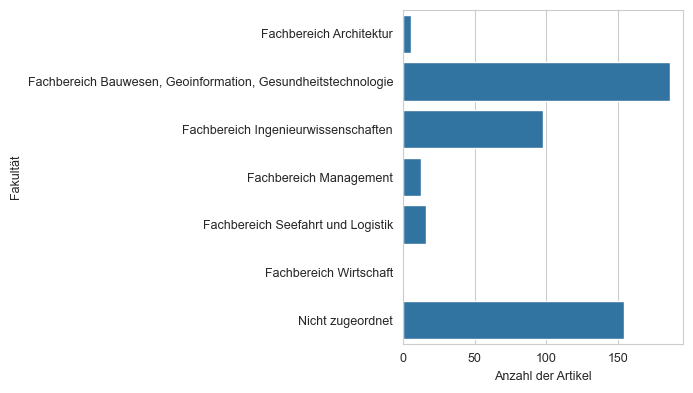

In [76]:
df_plot = df_with_inst.groupby(['fak_name'], dropna=False)['openalex_id'].count().reset_index()
df_plot.fillna('Nicht zugeordnet', inplace=True)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=df_plot, 
            x='openalex_id', 
            y='fak_name',
            ax=ax)

ax.set(xlabel='Anzahl der Artikel', ylabel='Fakultät')

plt.tight_layout()

plt.show()

In [77]:
df_plot[df_plot.fak_name != 'Nicht zugeordnet'].openalex_id.sum() / df_plot.openalex_id.sum()

0.6751054852320675

In [58]:
MAPPING_DICT_DEPT = {
    'Fachbereich Seefahrt und Logistik': {},
    'Fachbereich Architektur': {
        #'Institut für Architektur und Städtebau Oldenburg (IASO)': [],
        #'Institut für Baumanagement (IBM)': [],
        #'Institut für Intermediale Gestaltung und Darstellung (IGD)': [],
        #'Institut für nachhaltige Architektur und Umweltplanung (INAU)': [],
    },
    'Fachbereich Bauwesen, Geoinformation, Gesundheitstechnologie': {
        'Institut für Hörtechnik und Audiologie': ['hearing technology', 'acoustics', 'audiolog(ie|y)'],
        'Institut für Technische Assistenzsysteme (ITAS)': ['technical (assistance|assistive)', 'assistive technologies'],
        #'Public Health M.Sc.': [],
        'Studiengang Angewandte Pflegewissenschaft': ['pflegewissenschaft'],
        'Studiengang Logopädie': ['logopädie'],
        'IAPG Institut für Angewandte Photogrammetrie und Geoinformatik (Standort Oldenburg)': ['photogramm(m)?etr(ie|y)'],
        'Institut für Mess- und Auswertetechnik (IMA)': ['auswertetechnik'],
        'Bauchemisches Labor': ['bauchemisches labor'],
        'Baustoffprüflabor - Institut für Materialprüfung': ['materialprüfung'],
    },
    'Fachbereich Ingenieurwissenschaften': {
        #'Fachgebiet Informationstechnologie im Maschinenbau': [],
        #'Institut für C-Techniken (ICT)': [],
        #'Institut für Energie-, Verfahrens- und Umwelttechnik (EVU)': [],
        #'Institut für Konstruktions- und Produktionstechnik (IKP)': [],
        #'Institut für nachhaltige Energieversorgung (InEv)': [],
        #'Studiengang Elektrotechnik (Bachelor)': [],
    },
    'Fachbereich Management, Information, Technologie (MIT)': {
        #'Institut für Medienwirtschaft und Journalismus (InMWJ)': [],
        #'Institut für Wirtschaftsinformatik (IfW)': [],
    },
    'Fachbereich Wirtschaft und Gesellschaft': {}
}

In [59]:
with open('./mapping_tables_dept/jade.json', mode='w', encoding='utf-8') as f:
    json.dump(MAPPING_DICT_DEPT, f, ensure_ascii=False)

In [60]:
def map_dept(address: str, faculty: str) -> Union[str, None]:
    if faculty in MAPPING_DICT_DEPT:
        for k, v in MAPPING_DICT_DEPT.get(faculty).items():
            pattern = re.compile(r'|'.join(v), re.IGNORECASE)
            res = bool(pattern.search(address))
            if res:
                return k
        return None
    else:
        return None

In [65]:
df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften', 'dept_name'] = \
    df_with_inst.loc[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften']['raw_affiliation_string'].apply(map_dept, 
                                                                                    faculty='Fachbereich Ingenieurwissenschaften')

In [66]:
df_with_inst[(df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften') & df_with_inst['dept_name'].isnull()].raw_affiliation_string.unique()[0:]

array(['Department of Engineering Sciences, Jade University of Applied Sciences, Wilhelmshaven, Germany',
       'Department of Engineering, Jade University of Applied Sciences, 26389 Wilhelmshaven, Germany',
       'Jade University of Applied Sciences, Department of Engineering, Friedrich-Paffrath-Str. 101, 26389 Wilhelmshaven, Germany',
       'Fachbereich Ingenieurwissenschaften, Jade Hochschule, Friedrich-Paffrath-Straße\xa0101, 26389, Wilhelmshaven, Deutschland',
       'Jade University of Applied Sciences,Department of Engineering,Wilhelmshaven,Germany,26389',
       'Department of Engineering, Jade University of Applied Science, Wilhelmshaven',
       'Department of Engineering Science, Jade University of Applied Sciences, Wilhelmshaven, Germany',
       'Jade University of Applied Sciences,Department of Engineering Science,Wilhelmshaven,Germany',
       'Department of Engineering, Jade University of Applied Sciences, Wilhelmshaven, Germany',
       'Jade University of Applied S

In [67]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften'].groupby(['dept_name'], dropna=False)['openalex_id'].count().reset_index()

,dept_name,openalex_id
0,NaN,98


In [68]:
df_with_inst[df_with_inst['fak_name'] == 'Fachbereich Ingenieurwissenschaften']

,fak_name,parent_name,raw_affiliation_string,openalex_id,dept_name
2,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering Sciences, Jade Unive...",https://openalex.org/W4213021463,None
9,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Jade University of ...",https://openalex.org/W4220892610,None
18,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences, Departmen...",https://openalex.org/W4308629221,None
20,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Fachbereich Ingenieurwissenschaften, Jade Hoch...",https://openalex.org/W4281609022,None
26,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Department...",https://openalex.org/W4224253720,None
...,...,...,...,...,...
456,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Research Group for Modelling and Simulation of...,https://openalex.org/W3188734658,None
457,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Jade University of Applied Sciences,Department...",https://openalex.org/W4213149706,None
465,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,"Department of Engineering, Jade University of ...",https://openalex.org/W3187333733,None
466,Fachbereich Ingenieurwissenschaften,Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth,Department of Engineering Jade University of A...,https://openalex.org/W3187333733,None
